In [1]:
import torch
from calibr_polar import *
import copy

import matplotlib.pyplot as plt

In [49]:
device = torch.device('cpu')

In [84]:
#res1, res2, res3, res4, res5, res6 = extract_calibr('\\\\NAS_LOCCO\\Amaury\\data\\4polar_data_raw\\2026_01_16_calibr_polar_objectif\\Calib_Polar_2026-01-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')
res1, res2, res3, res4, res5, res6 = extract_calibr('\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_19_calibration\\polar\\Calib_Polar_2026-02-19_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [85]:
zer = zero('\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_19_calibration\\polar\\Calib_Polar_2026-02-19_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [88]:
intensity = open_ome('\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_19_calibration\\intensity\\Calib_Polar_2026-02-19\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [89]:
i1, i2, i3, i4, i5, i6 = extract_sqr(intensity)

In [90]:
i1-=zer
i2-=zer
i3-=zer
i4-=zer
i5-=zer
i6-=zer

In [91]:
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

In [92]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

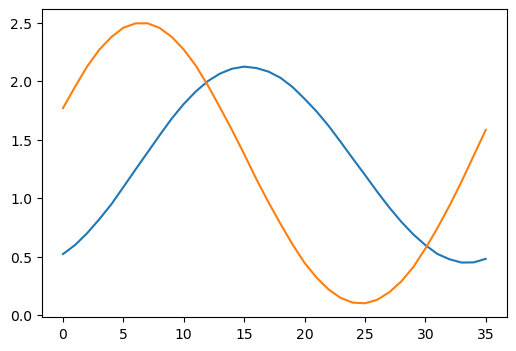

In [93]:
plt.plot(res1)
#plt.plot(res2)
plt.plot(res3)
#plt.plot(res4)
#plt.plot(res5)
#plt.plot(res6)

In [94]:
a1 = 1.
b1 = 0.001
b2 = 0.001
c1 = 0.001
c2 = 0.001
d1 = -1.
d2 = 0.001

I0 = 1.
offset=0*np.pi/180.
alpha = -22.
alpha_start = copy.deepcopy(alpha)

In [95]:
def through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset):
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    phii = (torch.linspace(np.pi/2, 1.5*np.pi, 37).to(device)+offset)[:-1]
    input_ = I0*torch.stack([torch.cos(phii), torch.sin(phii)]).to(device).to(torch.complex128)
    output_ = torch.einsum('ab,bc->ac', J, input_)
    #aa1, bb1, bb2, cc1, cc2, dd1, dd2 = 1.0065e+00,  1.1120e-02,  2.1056e-02, -4.6805e-02, -1.7288e-01,  9.9881e-01,  1.5819e-01
    #Jw = J = torch.tensor([
     #   [aa1, bb1 + 1j*bb2],
     #   [cc1 + 1j*cc2, dd1 + 1j*dd2]
   #]
   # ).to(torch.complex128)
    output_2 =  rotation(alpha, output_) #torch.einsum('ab,bc->ac', Jw, rotation(alpha, output_))
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [96]:
def rotation(alpha, inp): # input is a vector Ex, Ey
    alpha = alpha*torch.pi/180
    Rot = torch.stack([
        torch.stack([torch.cos(alpha), -torch.sin(alpha)]),
        torch.stack([torch.sin(alpha),torch.cos(alpha)])
    ]).to(torch.complex128)
    lambda_2 = torch.tensor([
    [1., 0.],
    [0., -1.]
    ]).to(torch.complex128).to(device)
    final = torch.einsum('ab,bc->ac', Rot, torch.einsum('ab,bc->ac', lambda_2, torch.inverse(Rot)))
    return torch.einsum('ab,bc->ac', final, inp)

In [97]:
res1 = torch.tensor(res1, device=device)
res2 = torch.tensor(res2, device=device)
res3 = torch.tensor(res3, device=device)
res4 = torch.tensor(res4, device=device)
res5 = torch.tensor(res5, device=device)
res6 = torch.tensor(res6, device=device)

In [98]:
params = torch.tensor([I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=.25)
loss_ = []

In [99]:
def loss_f(para):
    I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset = para[0], para[1], para[2], para[3], para[4], para[5], para[6], para[7] , para[8], para[9]
    th1, th2, th3, th4 = through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset) 
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    force_angle = ((alpha-alpha_start)**2)/1000
    force_offset = (offset**2)/100
    force_unitary = 0#0.00001*torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
    #force_unitary = (a1**2+b1**2+b2**2+c1**2+c2**2+d1**2+d2**2-1)**2
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + (I0-torch.abs(I0))**2 + force_offset + (a1-torch.abs(a1))**2 + force_angle + force_unitary

In [100]:
for i in range(1000):
    optimizer.zero_grad()
    loss=loss_f(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.cpu().detach().numpy())

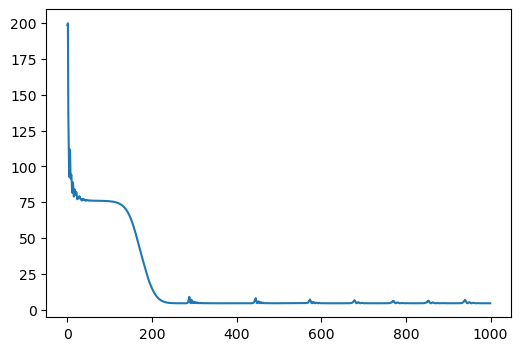

In [101]:
plt.plot(loss_)

In [102]:
print('I0 = ', params[0].cpu().detach().numpy())
print('J = ', params[1].cpu().detach().numpy(), '                   ', params[2].cpu().detach().numpy(), '+ i ', params[3].cpu().detach().numpy())
print('     ', params[4].cpu().detach().numpy(), '+ i ', params[5].cpu().detach().numpy(), '   ', params[6].cpu().detach().numpy(), '+ i ', params[7].cpu().detach().numpy())
print('angle : ', params[8].cpu().detach().numpy())
print('offset : ', params[9].cpu().detach().numpy()*180/np.pi)

I0 =  0.8912397
J =  1.4368184                     -0.813716 + i  0.75972545
      -0.86022186 + i  0.62033254     -1.4429442 + i  0.05129119
angle :  -67.67472
offset :  -23.225844829216797


In [103]:
jj = np.array([[0.5977892, -0.067152604 + 1j*  -0.3144654],[0.11054159 + 1j*  -0.27431256, 0.59944284 + 1j*  0.09444063]])/0.5977892
print(jj)

[[ 1.        +0.j         -0.11233492-0.52604731j]
 [ 0.18491734-0.45887841j  1.00276626+0.15798317j]]


In [104]:
I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset = params[0].cpu(), params[1].cpu(), params[2].cpu(), params[3].cpu(), params[4].cpu(), params[5].cpu(), params[6].cpu(), params[7].cpu() , params[8].cpu(), params[9].cpu()
J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
force_unitary = torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
print(force_unitary)

tensor(19.3470, dtype=torch.float64, grad_fn=<SumBackward0>)


In [105]:
J_dichroic = torch.tensor([[0.7838338      ,               -0.25981125 + 1j*  -0.48329058],[
      -0.4230177 + 1j*  0.27765664  ,   -0.7788276 + 1j*  -0.28660256
]]).to(device) # the main one used for the data processing

In [116]:
predicted1, predicted2, predicted3, predicted4 = through_microscope(params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7], params[8], params[9])
predicted1, predicted2, predicted3, predicted4 = through_microscope(1.8,J_dichroic[0,0], torch.real(J_dichroic[0,1]), 
                                                                    torch.imag(J_dichroic[0,1]), torch.real(J_dichroic[1,0]), 
                                                                    torch.imag(J_dichroic[1,0]),torch.real(J_dichroic[1,1]), 
                                                                    torch.imag(J_dichroic[1,1]), torch.tensor(24).to(device), 
                                                                    torch.tensor(0.).to(device))
predicted1 = predicted1.cpu().detach().numpy()
predicted2 = predicted2.cpu().detach().numpy()
predicted3 = predicted3.cpu().detach().numpy()
predicted4 = predicted4.cpu().detach().numpy()

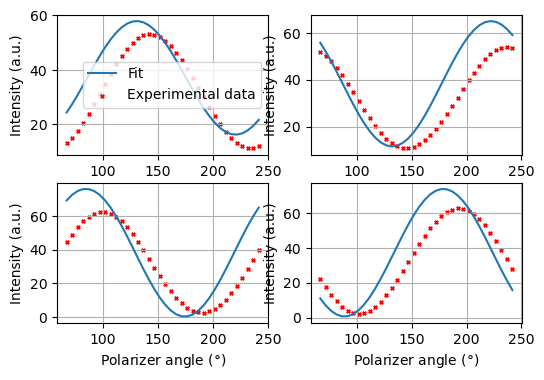

In [117]:
plt.rcParams['figure.figsize'] = [6, 4]
fig, ax = plt.subplots(2,2)
phi = (np.linspace(np.pi/2, 1.5*np.pi, 37)+params[9].detach().numpy())[:-1]
ax[0,0].plot(phi*180/np.pi, predicted1/0.04, label = 'Fit')
ax[0,0].scatter(phi*180/np.pi, res1/0.04, c='r', marker='x', s=6, label = 'Experimental data')
ax[0,0].legend()
#ax[0,0].set_ylim((0., 1))
ax[0,0].grid()
ax[0,0].set_xlabel('Polarizer angle ($\\degree$)')
ax[0,0].set_ylabel('Intensity (a.u.)')
ax[0,1].plot(phi*180/np.pi, predicted2/0.04)
ax[0,1].scatter(phi*180/np.pi, res2/0.04, c='r', marker='x', s=6)
#ax[0,1].set_ylim((0., 1))
ax[0,1].grid()
ax[0,1].set_xlabel('Polarizer angle ($\\degree$)')
ax[0,1].set_ylabel('Intensity (a.u.)')
ax[1,0].plot(phi*180/np.pi, predicted3/0.04)
ax[1,0].scatter(phi*180/np.pi, res3/0.04, c='r', marker='x', s=6)
#ax[1,0].set_ylim((0., 1))
ax[1,0].grid()
ax[1,0].set_xlabel('Polarizer angle ($\\degree$)')
ax[1,0].set_ylabel('Intensity (a.u.)')
ax[1,1].plot(phi*180/np.pi, predicted4/0.04)
ax[1,1].scatter(phi*180/np.pi, res4/0.04, c='r', marker='x', s=6)
#ax[1,1].set_ylim((0., 1))
ax[1,1].grid()
ax[1,1].set_xlabel('Polarizer angle ($\\degree$)')
ax[1,1].set_ylabel('Intensity (a.u.)')
plt.savefig("calibr.svg", format="svg")

# Calibration before grating

In [150]:
res1, res2, res3, res4, res5, res6 = extract_calibr('Z:\\DATA\\4polar_data_raw\\2026_01_16_calibr_polar_inside\\Calib_Polar_2026-01-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [151]:
#zer = zero('Z:\\DATA\\4polar_data\\2025-12-16 - calibration_polarizeur_after_grating_graduations_microscope_side\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')
zer = np.min(np.array([np.min(res1), np.min(res2), np.min(res3), np.min(res4), np.min(res5), np.min(res6)]))
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

In [152]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

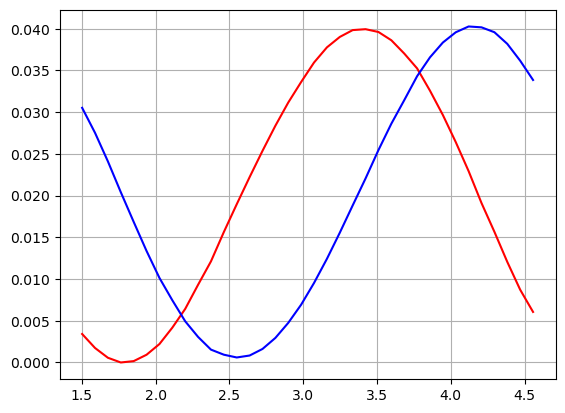

In [153]:
plt.plot(phi, res1, c='r')
#plt.plot(phi, res2, c='g')
plt.plot(phi, res3, c='b')
#plt.plot(phi, res4, c='y')
#plt.plot(phi, res5)
#plt.plot(phi, res6)
plt.grid()

In [154]:
res1 = torch.tensor(res1.copy(), device=device)
res2 = torch.tensor(res2.copy(), device=device)
res3 = torch.tensor(res3.copy(), device=device)
res4 = torch.tensor(res4.copy(), device=device)
res5 = torch.tensor(res5.copy(), device=device)
res6 = torch.tensor(res6.copy(), device=device)

In [170]:
def through_end_microscope(I0, angle, offset):
    phii = (torch.linspace(np.pi/2, 1.5*np.pi, 37)+offset)[:-1]
    input_ = I0*torch.stack([torch.cos(phii), torch.sin(phii)]).to(device).to(torch.complex128)
    output_ = input_
    '''
    J2 = torch.stack([
        torch.stack([e1, f1 + 1j*f2]),
        torch.stack([g1 + 1j*g2, h1 + 1j*h2])
    ]
    ).to(torch.complex128)'''
    output_2 =  rotation(angle, output_) #torch.einsum('ab,bc->ac', J2, rotation(angle, output_))
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [173]:
def loss_f2(para):
    #I0, angle, e1, f1, f2, g1, g2, h1, h2, offset = para[0], para[1], para[2], para[3], para[4], para[5], para[6], para[7], para[8], para[9]
    I0, angle, offset = para[0], para[1], para[2]
    th1, th2, th3, th4 = through_end_microscope(I0, angle,offset) 
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + (I0-torch.abs(I0))**2 + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + (offset**2)/200 #+ 0.01*(angle-22.5)**2

In [174]:
params = torch.tensor([0.3, 22.5, 0.0001], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=1.)
loss_ = []

In [175]:
for i in range(4000):
    optimizer.zero_grad()
    loss=loss_f2(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.detach().numpy())

In [177]:
predicted1, predicted2, predicted3, predicted4 = through_end_microscope(params[0], params[1], params[2])
predicted1 = predicted1.detach().numpy()
predicted2 = predicted2.detach().numpy()
predicted3 = predicted3.detach().numpy()
predicted4 = predicted4.detach().numpy()

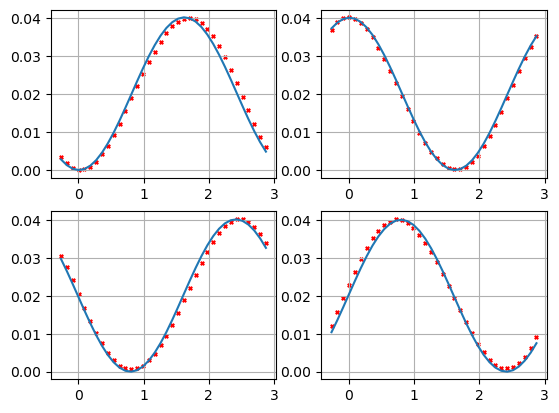

In [179]:
fig, ax = plt.subplots(2,2)
#phi1 = np.linspace(0+params[2].detach().numpy()*np.pi/180, np.pi+params[2].detach().numpy()*np.pi/180, 36)
phi2 = np.linspace(0, np.pi, 36)+params[2].detach().numpy()
phi1=phi2
ax[0,0].plot(phi1, predicted1)
ax[0,0].scatter(phi2, res1, c='r', marker='x', s=6)
ax[0,0].grid()
ax[0,1].plot(phi1, predicted2)
ax[0,1].scatter(phi2, res2, c='r', marker='x', s=6)
ax[0,1].grid()
ax[1,0].plot(phi1, predicted3)
ax[1,0].scatter(phi2, res3, c='r', marker='x', s=6)
ax[1,0].grid()
ax[1,1].plot(phi1, predicted4)
ax[1,1].scatter(phi2, res4, c='r', marker='x', s=6)
ax[1,1].grid()

In [180]:
params

tensor([ 0.2004, 22.0160, -0.2675], requires_grad=True)

In [232]:
params[2]*180/np.pi

tensor(-2.9269, grad_fn=<DivBackward0>)